# PyTorch 시작하기

> Tensor
> - basic
> - operation
>
>  Autograd
>  - PyTorch에서 지원하는 경사하강법 직접 구현하기

## Basic
#### 1️⃣ Tensor : vector / matrix
Pytorch 연산의 기본 단위는 **tensor**다.  

tensor의 연산과 행렬곱에 대해 살펴보자.

In [1]:
import torch

In [2]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(x)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])


In [3]:
print("Size: ", x.size())
print("Shape: ", x.shape)
print("rank(차원): ", x.ndimension())

Size:  torch.Size([3, 3])
Shape:  torch.Size([3, 3])
rank(차원):  2


#### 2️⃣unsqueeze, squeeze, view
- tensor rank, shape 바꾸기
- **원소 개수는 변하지 않는다.**

In [4]:
# unsqueeze - rank 늘리기
x = torch.unsqueeze(x, 0)
print(x)
print("Size: ", x.size())
print("Shape: ", x.shape)
print("rank(차원): ", x.ndimension())

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])
Size:  torch.Size([1, 3, 3])
Shape:  torch.Size([1, 3, 3])
rank(차원):  3


tensor x 의 0번째 차원이 1 증가해 shape이 [1, 3, 3]으로 늘었다

In [5]:
# squeeze - rank 줄이기
x = torch.squeeze(x)
print(x)
print("Size: ", x.size())
print("Shape: ", x.shape)
print("rank(차원): ", x.ndimension())

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Size:  torch.Size([3, 3])
Shape:  torch.Size([3, 3])
rank(차원):  2


1인 rank를 삭제한다.

view - shape를 직접 지정한다.

단, 원소 개수는 불변하여 일치하지 않는 경우 오류가 난다.

In [6]:
x = x.view(9)
print(x)
print("Size: ", x.size())
print("Shape: ", x.shape)
print("rank(차원): ", x.ndimension())

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])
Size:  torch.Size([9])
Shape:  torch.Size([9])
rank(차원):  1


In [7]:
try:
    x = x.view(2, 4)
except Exception as e:
    print(e)

shape '[2, 4]' is invalid for input of size 9


원소 개수가 9개 이므로 원소가 8인 tensor로 변환 불가하다.

#### 3️⃣ 행렬곱 : torch.mm()  
⚠️ **A의 열 수와 B의 행 수가 일치해야 한다.**

In [8]:
w = torch.randn(5, 3, dtype=torch.float)
z = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

print(w.size())
print(z.size())

torch.Size([5, 3])
torch.Size([3, 2])


In [9]:
print(w)
print(z)

tensor([[-0.5548,  0.8682, -1.6900],
        [-0.3039,  0.0220,  1.7964],
        [-0.5106, -0.8202,  0.4953],
        [ 0.3295, -1.5379,  0.5270],
        [-0.4867, -1.1992,  0.2386]])
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])


In [10]:
b = torch.randn(5, 2, dtype=torch.float)
print(b.size())
print(b)

torch.Size([5, 2])
tensor([[-1.4596,  0.1051],
        [ 1.3996,  1.5382],
        [ 0.1467,  0.3486],
        [ 0.8574,  0.8656],
        [ 0.0202,  0.2140]])


In [11]:
wz = torch.mm(w, z)
print(wz)
print(wz.size())

tensor([[-6.4001, -7.7767],
        [ 8.7445, 10.2591],
        [-0.4948, -1.3304],
        [-1.6492, -2.3307],
        [-2.8912, -4.3384]])
torch.Size([5, 2])


In [12]:
result = wz + b
print(result.size())
print(result)

torch.Size([5, 2])
tensor([[-7.8597, -7.6716],
        [10.1440, 11.7973],
        [-0.3481, -0.9818],
        [-0.7918, -1.4650],
        [-2.8710, -4.1245]])


## Autograd
자동 기울기 : 기울기를 자동으로 계산한다.

> - 경사하강법  
> 오차를 수학함수로 표현하여 미분값인 기울기를 이용해 오차를 최소화하는 알고리즘이다.  
    >   - 오차 : 실제값 - 예측값
>    
>    최적화 방향은 기울기 값의 반대방향이 된다.

### 오염된 이미지 복원하기
PyTorch에서 지원하는 경사하강법을 직접 구현하여 그 동작을 이해해보자.

In [1]:
# import libraries
import torch
import matplotlib.pyplot as plt
import pickle

In [3]:
# Load Image
# broken_image = torch.tensor(pickle.load(open('./broken_image_t.p', 'rb'), dtype=float, encoding='latin1'))
broken_image = torch.FloatTensor(pickle.load(open('./broken_image_t.p', 'rb'), encoding='latin1'))
print(broken_image.shape)

torch.Size([10000])


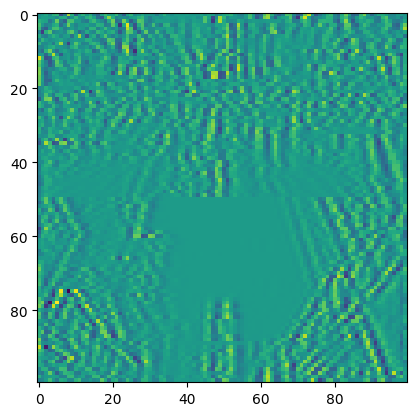

In [5]:
plt.imshow(broken_image.view(100, 100))

In [7]:
# weird_function - 오염된 이미지 발생시키는 함수
def weird_function(x, n_iter=5):
    h = x    
    filt = torch.tensor([-1./3, 1./3, -1./3])
    for i in range(n_iter):
        zero_tensor = torch.tensor([1.0*0])
        h_l = torch.cat( (zero_tensor, h[:-1]), 0)
        h_r = torch.cat((h[1:], zero_tensor), 0 )
        h = filt[0] * h + filt[2] * h_l + filt[1] * h_r
        if i % 2 == 0:
            h = torch.cat( (h[h.shape[0]//2:],h[:h.shape[0]//2]), 0  )
    return h

In [28]:
# random_tensor 정의
random_tensor = torch.randn(10000, dtype=torch.float)

random_tensor를 weird_function에 입력시킨 후 결과값이 오염된 값과 같을 때, random_tensor가 원본 이미지라고 할 수 있다.

이 점을 인지하여 원본 이미지를 복원시켜 보겠다.

In [12]:
# 학습률
lr = 0.8

In [14]:
def dist_loss(hypothesis, broken_image) : 
    return torch.dist(hypothesis, broken_image)

In [30]:
for i in range(20000):
    random_tensor.requires_grad_(True)
    hypothesis = weird_function(random_tensor)
    loss = dist_loss(hypothesis, broken_image)
    # backward propagation
    loss.backward()
    with torch.no_grad():
        random_tensor = random_tensor - lr * random_tensor.grad
    if i % 1000 == 0:
        print(i, loss.item())

0 12.338044166564941
1000 1.1369961500167847
2000 0.5425699949264526
3000 0.37455469369888306
4000 0.2940739691257477
5000 0.24516333639621735
6000 0.2107374668121338
7000 0.18374726176261902
8000 0.16095897555351257
9000 0.14075902104377747
10000 0.12227045744657516
11000 0.1049785166978836
12000 0.0885605588555336
13000 0.0728026032447815
14000 0.05755602940917015
15000 0.042714398354291916
16000 0.028201349079608917
17000 0.02115481160581112
18000 0.021165385842323303
19000 0.021167226135730743


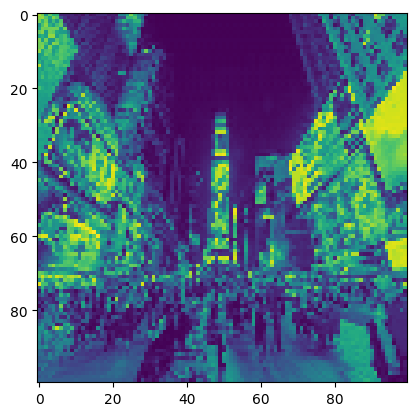

In [31]:
plt.imshow(random_tensor.view(100, 100).data)